In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
pd.options.display.float_format = '{:,.2f}'.format

In [5]:
df = pd.read_csv('../Data/cost_revenue.csv')

In [6]:
df.head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
0,5293,8/2/1915,The Birth of a Nation,"$110,000","$11,000,000","$10,000,000"
1,5140,5/9/1916,Intolerance,"$385,907",$0,$0
2,5230,12/24/1916,"20,000 Leagues Under the Sea","$200,000","$8,000,000","$8,000,000"
3,5299,9/17/1920,Over the Hill to the Poorhouse,"$100,000","$3,000,000","$3,000,000"
4,5222,1/1/1925,The Big Parade,"$245,000","$22,000,000","$11,000,000"


---

**Data Type Conversion**

In [9]:
chars_to_remove = ['$', ',']

columns_to_clean = ['USD_Production_Budget', 'USD_Worldwide_Gross', 'USD_Domestic_Gross']

for col in columns_to_clean:
    for char in chars_to_remove:
        df[col] = df[col].astype(str).str.replace(char, '')
    df[col] = pd.to_numeric(df[col])

df.Release_Date = pd.to_datetime(df.Release_Date)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5391 entries, 0 to 5390
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Rank                   5391 non-null   int64         
 1   Release_Date           5391 non-null   datetime64[ns]
 2   Movie_Title            5391 non-null   object        
 3   USD_Production_Budget  5391 non-null   int64         
 4   USD_Worldwide_Gross    5391 non-null   int64         
 5   USD_Domestic_Gross     5391 non-null   int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 252.8+ KB


---
**International Releases**

In [17]:
international_releases = df.loc[(df.USD_Domestic_Gross == 0) & (df.USD_Worldwide_Gross != 0)]
international_releases = df.query('USD_Domestic_Gross == 0 and USD_Worldwide_Gross != 0')
international_releases.sample(3)

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
4937,2000,2015-06-30,Viy,26000000,34246770,0
3049,1927,2007-12-31,Alatriste,28000000,22860477,0
4522,1860,2013-12-31,Space Pirate Captain Harlock,30000000,143490,0


---
**Production Costs Exceeded the Worldwide Gross Revenue**

In [22]:
future_releases = df[df.Release_Date >= '2018-5-1']
df_clean = df.drop(future_releases.index)

money_losing = df_clean.loc[df_clean.USD_Production_Budget > df_clean.USD_Worldwide_Gross]

---
**Visualization**

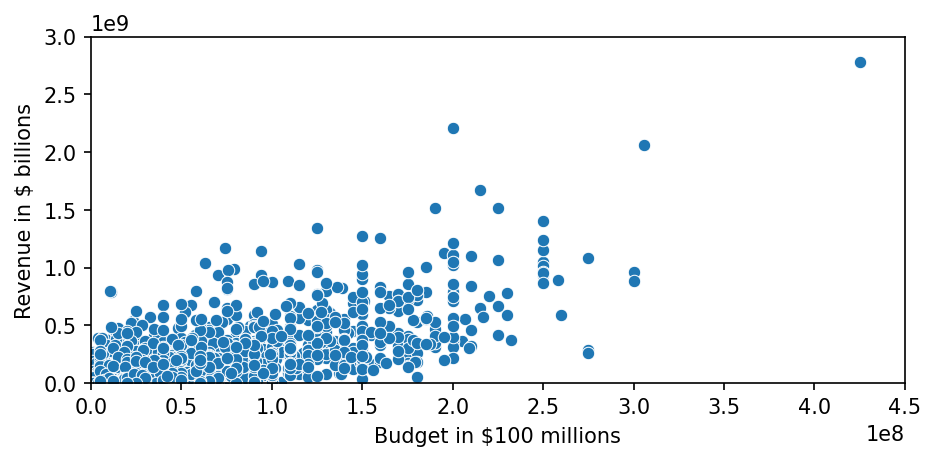

In [32]:
plt.figure(figsize=(7,3), dpi=150)

ax = sns.scatterplot(data=df_clean, x= 'USD_Production_Budget', y= 'USD_Worldwide_Gross')

ax.set(ylim=(0, 3000000000),
       xlim=(0, 450000000),
       ylabel='Revenue in $ billions',
       xlabel='Budget in $100 millions')

plt.show()

---
**Regression**

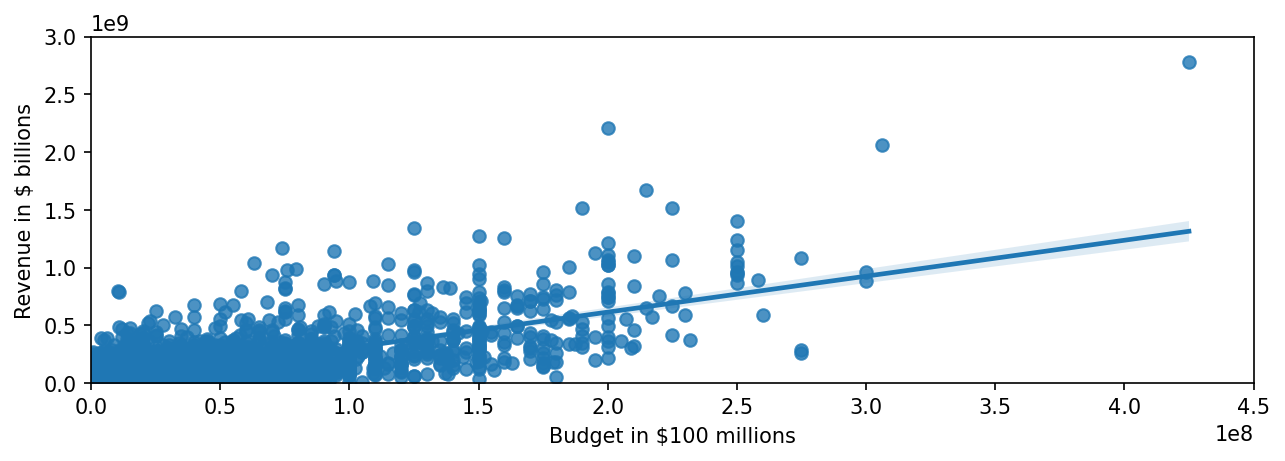

In [38]:
plt.figure(figsize=(10,3), dpi=150)

ax = sns.regplot(data=df_clean, x= 'USD_Production_Budget', y= 'USD_Worldwide_Gross')

ax.set(ylim=(0, 3000000000),
         xlim=(0, 450000000),
         ylabel='Revenue in $ billions',
         xlabel='Budget in $100 millions')

plt.show()

In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
regression = LinearRegression()

In [46]:
x = pd.DataFrame(df_clean, columns=['USD_Production_Budget'])
y = pd.DataFrame(df_clean, columns=['USD_Production_Budget'])

regression.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
budget = 350000000
revenue_estimate = regression.intercept_[0] + regression.coef_[0,0] * budget
revenue_estimate = round(revenue_estimate, -6)

print(f'The estimated revenue for a $350 film is around {revenue_estimate}.')

The estimated revenue for a $350 film is around 350000000.0.
